# 10 — Fine-tuning data prep: composition, leakage check, worked examples (E8, M7, T7.11)

Story notebook for Milestone 7's fine-tuning data-prep work (PLAN.md §3 E8, §10; full task
breakdown in `M7.md`). Thin (PLAN.md §6): every table below reads an already-committed
manifest or CSV that T7.2–T7.9 already produced — the context sampler (T7.2), teacher
generation (T7.3), constructed abstentions (T7.4), the quality filter (T7.5), the leakage
guard and train/val/probe split (T7.6), and the prompt-length probe (T7.9). This notebook
makes **no API calls** (the leakage check re-runs live, but purely locally — difflib plus,
where `sentence-transformers` is importable in this kernel, the embedding backstop; neither
needs a network call) and needs no API key, so re-running it top to bottom costs nothing.

**Read this before the tables below: the committed data is a pilot, not the full sweep.**
`configs/finetune.yaml` targets 500 sampled context groups; this build attempted teacher
generation on 10 of them, yielding 39 filtered examples, all of which landed in the `probe`
split — `train.jsonl` and `val.jsonl` are currently empty. This is a deliberate, resumable
pilot (T7.3's `generate_pairs.py` is incremental/append-and-skip), not a partial failure; see
`data/finetune/finetune_data_datasheet.md` and `reports/finetune_plan_v1.md` (T7.10) for the
full reasoning. Every number below is what it honestly is at this scale — small counts are
not smoothed over.

In [1]:
import json

import pandas as pd
from IPython.display import Markdown, display

from cragb.finetune.schema import load_training_examples_jsonl
from cragb.finetune.split import (
    guard_leakage,
    load_cragb_question_hashes,
    load_cragb_questions,
    load_split_config,
)
from cragb.utils.io import load_config, resolve_path

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

## 1. Training-context sampling funnel + category composition (T7.2)

`sample_contexts.py` groups `corpus_v1` reviews by product (`parent_asin`, k=5 reviews/group),
after excluding every document CRAGB's evidence (`relevant_ids`/`cited_doc_ids`/pooled
candidates) touches, then stratifies to the taxonomy category mix.

In [2]:
contexts_manifest = json.loads(resolve_path("data/finetune/contexts_v1_manifest.json").read_text(encoding="utf-8"))

print(
    f"{contexts_manifest['n_docs_excluded_as_cragb_evidence']} CRAGB-evidence documents "
    f"(across {contexts_manifest['n_parent_asins_excluded']} products) excluded before sampling.\n"
    f"{contexts_manifest['n_groups']} context groups sampled "
    f"(target: {load_config('configs/finetune.yaml')['sampling']['n_contexts']}).\n"
    f"Photo-bearing share: {contexts_manifest['photo_bearing_share']:.1%} "
    f"(target >= {contexts_manifest['photo_bearing_target_share']:.0%})."
)

1097 CRAGB-evidence documents (across 1070 products) excluded before sampling.
377 context groups sampled (target: 500).
Photo-bearing share: 83.8% (target >= 30%).


In [3]:
quota_report = pd.DataFrame.from_dict(contexts_manifest["category_quota_report"], orient="index")
quota_report.index.name = "category"
display(quota_report)

,target,actual,shortfall
category,,,
fit_sizing,100,100,0
colour_appearance,67,67,0
fabric_quality,83,83,0
durability,67,15,52
defects,67,11,56
occasion,67,52,15
value,49,49,0


`durability` and `defects` fall well short of their nominal quota (shortfall 52 and 56 of a
target 67 each) — too little corpus evidence survives the CRAGB-evidence exclusion for those
two categories, a property of the *sampling* stage, not a generation-time shortfall.

## 2. Quality filter funnel (T7.5)

Stage 1 (deterministic, free): citation validity + format compliance. Stage 2 (judged):
faithfulness ≥ 4 only — `results/tables/judge_validation_v1.csv` (T4b.6) found faithfulness
the only judge criterion above the project's 0.4 usability bar (κ=0.597; correctness,
completeness, conciseness all below it). Abstentions bypass stage 2 (nothing to be faithful
*to*).

In [4]:
filter_report = pd.read_csv(resolve_path("results/tables/ft_filter_v1.csv"))
display(filter_report)

,slice,n_raw,n_dropped_citation_invalid,n_dropped_format,n_dropped_low_faithfulness,n_accepted,judge_n_calls,judge_n_cache_hits,judge_total_prompt_tokens,judge_total_completion_tokens,judge_total_usd
0,overall,39,0,0,0,39,29.0,0.0,31132.0,2237.0,0.02539
1,category:fabric_quality,2,0,0,0,2,NaN,NaN,NaN,NaN,NaN
2,category:fit_sizing,36,0,0,0,36,NaN,NaN,NaN,NaN,NaN
3,category:value,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN
4,is_abstention:False,29,0,0,0,29,NaN,NaN,NaN,NaN,NaN
5,is_abstention:True,10,0,0,0,10,NaN,NaN,NaN,NaN,NaN


In [5]:
overall = filter_report[filter_report["slice"] == "overall"].iloc[0]
assert overall["n_raw"] == (
    overall["n_dropped_citation_invalid"]
    + overall["n_dropped_format"]
    + overall["n_dropped_low_faithfulness"]
    + overall["n_accepted"]
), "filter funnel arithmetic does not close"
print(
    f"{int(overall['n_raw'])} raw -> {int(overall['n_dropped_citation_invalid'])} dropped "
    f"(citation) + {int(overall['n_dropped_format'])} dropped (format) + "
    f"{int(overall['n_dropped_low_faithfulness'])} dropped (faithfulness) -> "
    f"{int(overall['n_accepted'])} accepted. Arithmetic closes."
)
if overall["n_accepted"] / overall["n_raw"] > 0.95:
    print(
        "Accept rate is above 95% -- at this pilot's n, plausible given a capable 120B "
        "teacher closely following a prompt that restates the citation rules, but too small "
        "a sample to conclude the threshold is doing nothing; re-check once the full sweep runs."
    )

39 raw -> 0 dropped (citation) + 0 dropped (format) + 0 dropped (faithfulness) -> 39 accepted. Arithmetic closes.
Accept rate is above 95% -- at this pilot's n, plausible given a capable 120B teacher closely following a prompt that restates the citation rules, but too small a sample to conclude the threshold is doing nothing; re-check once the full sweep runs.


## 3. Leakage guard, run live (T7.6)

This is the one check this notebook actually *runs*, not just reads — `cragb.finetune.split.guard_leakage`
(T7.6) is called here, live, against every filtered example (positives + constructed
abstentions), exactly as T7.6's own pipeline does. Three layers: exact-hash
(`cragb.bench.assemble.check_no_leakage`, T2.10), difflib near-duplicate, and (where
`sentence-transformers` is importable in this kernel) an embedding-cosine backstop.

In [6]:
import logging

# guard_leakage logs (at WARNING, with a full traceback) if sentence-transformers isn't
# importable in this kernel -- expected and handled below, not a notebook error, so it's
# quieted here rather than left to print a scary-looking stack trace above a "this is fine"
# explanation.
logging.getLogger("cragb.finetune.split").setLevel(logging.ERROR)

finetune_cfg = load_config("configs/finetune.yaml")
split_cfg = load_split_config("configs/finetune.yaml")

filtered_examples = load_training_examples_jsonl(finetune_cfg["paths"]["filtered_pairs_out"])
cragb_question_hashes = load_cragb_question_hashes(finetune_cfg["paths"]["cragb_leakage_manifest"])
cragb_questions = load_cragb_questions(finetune_cfg["paths"]["cragb_questions_in"])

leakage_report = guard_leakage(
    filtered_examples,
    cragb_question_hashes,
    cragb_questions,
    near_duplicate_threshold=split_cfg.near_duplicate_threshold,
    embedding_similarity_threshold=split_cfg.embedding_similarity_threshold,
    embedding_model_name=split_cfg.embedding_model,
)

print(f"checked: {leakage_report.n_checked} candidate examples")
print(f"exact leaks: {leakage_report.n_exact_leak}")
print(f"near-duplicates dropped: {leakage_report.n_near_duplicate}")
print(f"embedding backstop used: {leakage_report.embedding_backstop_used}")
print(f"survivors: {len(leakage_report.kept_example_ids)}")

checked: 39 candidate examples
exact leaks: 0
near-duplicates dropped: 0
embedding backstop used: False
survivors: 39


In [7]:
if leakage_report.near_duplicate_matches:
    near_dup_df = pd.DataFrame([m.to_dict() for m in leakage_report.near_duplicate_matches])
    display(near_dup_df)
else:
    print("No near-duplicates found.")

No near-duplicates found.


In [8]:
split_manifest = json.loads(resolve_path("data/finetune/split_manifest_v1.json").read_text(encoding="utf-8"))
assert leakage_report.n_exact_leak == split_manifest["n_dropped_exact_leak"], (
    "live leakage check disagrees with the committed split manifest's exact-leak count"
)
if leakage_report.embedding_backstop_used == split_manifest["embedding_backstop_used"]:
    # Same layers ran both times -> the counts must match exactly.
    assert leakage_report.n_near_duplicate == split_manifest["n_dropped_near_duplicate"], (
        "live leakage check disagrees with the committed split manifest's near-duplicate count"
    )
    print("Live re-run matches the committed split_manifest_v1.json exactly (same layers ran).")
else:
    # This kernel's sentence-transformers availability differs from whatever build produced
    # the committed manifest -- a difflib-only re-run legitimately catches fewer near-duplicates
    # than a run with the embedding backstop, and vice versa. Not a bug; report it as such.
    print(
        f"This kernel's embedding-backstop availability ({leakage_report.embedding_backstop_used}) "
        f"differs from the committed manifest's ({split_manifest['embedding_backstop_used']}), so "
        f"the near-duplicate counts legitimately differ: live={leakage_report.n_near_duplicate} vs "
        f"committed={split_manifest['n_dropped_near_duplicate']}. The exact-hash layer (the one "
        "guarantee that never depends on an optional dependency) matches in both cases: "
        f"{leakage_report.n_exact_leak} leaks."
    )

This kernel's embedding-backstop availability (False) differs from the committed manifest's (True), so the near-duplicate counts legitimately differ: live=0 vs committed=7. The exact-hash layer (the one guarantee that never depends on an optional dependency) matches in both cases: 0 leaks.


## 4. Train / val / probe composition (T7.6)

Grouped by `parent_asin` so no product straddles a split. At this pilot's scale, the entire
32-example surviving pool was absorbed by the probe set's 40-answerable/40-abstention target
— `train`/`val` are correctly reported empty rather than under-filling probe to leave
examples behind for them.

In [9]:
def composition_row(name, comp):
    return {
        "split": name,
        "n": comp["n"],
        "n_answerable": comp["n_answerable"],
        "n_abstention": comp["n_abstention"],
        "abstention_share": comp["n_abstention"] / comp["n"] if comp["n"] else None,
    }

composition = pd.DataFrame(
    [
        composition_row("train", split_manifest["train"]),
        composition_row("val", split_manifest["val"]),
        composition_row("probe", split_manifest["probe"]),
    ]
)
display(composition)

assert composition["n"].sum() == split_manifest["n_kept"], (
    "train+val+probe does not sum to the manifest's n_kept"
)
print(f"train + val + probe = {int(composition['n'].sum())} = n_kept ({split_manifest['n_kept']}). Closes.")

,split,n,n_answerable,n_abstention,abstention_share
0,train,0,0,0,NaN
1,val,0,0,0,NaN
2,probe,32,24,8,0.25


train + val + probe = 32 = n_kept (32). Closes.


In [10]:
probe_by_category = pd.Series(split_manifest["probe"]["per_category"], name="probe_n")
probe_by_category.index.name = "category"
display(probe_by_category.to_frame())

,probe_n
category,
fabric_quality,2
fit_sizing,29
value,1


## 5. Dataset composition figure

Stacked bar of accepted examples per taxonomy category, split by `is_abstention`, one panel
per split with any examples in it. At this pilot's scale only `probe` is non-empty and only
three categories are represented (`fit_sizing`, `fabric_quality`, `value`) — the figure shows
exactly that, not a smoothed or padded version of the target composition.

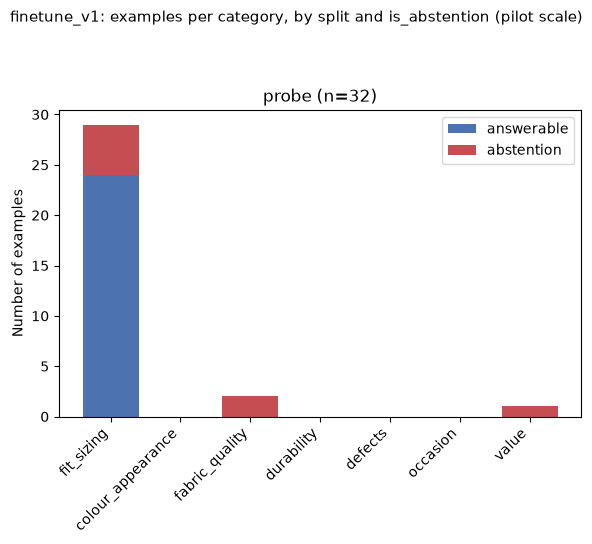

Figure's category counts sum to 32, matching split_manifest_v1.json's n_kept (32).


In [11]:
import matplotlib.pyplot as plt

all_categories = ["fit_sizing", "colour_appearance", "fabric_quality", "durability", "defects", "occasion", "value"]
splits_data = {"train": split_manifest["train"], "val": split_manifest["val"], "probe": split_manifest["probe"]}

# Per-split, per-category answerable/abstention counts -- per_category only gives combined
# totals, so re-derive the answerable/abstention breakdown per category from the raw files.
split_examples = {
    "train": load_training_examples_jsonl(finetune_cfg["paths"]["train_out"]),
    "val": load_training_examples_jsonl(finetune_cfg["paths"]["val_out"]),
    "probe": load_training_examples_jsonl(finetune_cfg["paths"]["probe_out"]),
}

nonempty_splits = [name for name, exs in split_examples.items() if exs]
fig, axes = plt.subplots(
    1, len(nonempty_splits), figsize=(max(6, 5 * len(nonempty_splits)), 5.5), squeeze=False
)
axes = axes[0]

for ax, split_name in zip(axes, nonempty_splits):
    exs = split_examples[split_name]
    answerable_counts = {c: 0 for c in all_categories}
    abstention_counts = {c: 0 for c in all_categories}
    for e in exs:
        target = abstention_counts if e.is_abstention else answerable_counts
        target[e.category] = target.get(e.category, 0) + 1

    x = range(len(all_categories))
    answerable_vals = [answerable_counts[c] for c in all_categories]
    abstention_vals = [abstention_counts[c] for c in all_categories]
    ax.bar(x, answerable_vals, label="answerable", color="#4C72B0")
    ax.bar(x, abstention_vals, bottom=answerable_vals, label="abstention", color="#C44E52")
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_categories, rotation=45, ha="right")
    ax.set_ylabel("Number of examples")
    ax.set_title(f"{split_name} (n={len(exs)})")
    ax.legend()

fig.suptitle(
    "finetune_v1: examples per category, by split and is_abstention (pilot scale)",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, 0.92])

fig_path = resolve_path("reports/figures/ft_dataset_composition_v1.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()

n_plotted = sum(len(exs) for exs in split_examples.values())
assert n_plotted == split_manifest["n_kept"], "figure's total example count doesn't match the split manifest"
print(f"Figure's category counts sum to {n_plotted}, matching split_manifest_v1.json's n_kept ({split_manifest['n_kept']}).")

## 6. Rendered-prompt token-length distribution (T7.9)

`max_seq_len` for the QLoRA feasibility probe (T7.9) was set from the *measured* p95 token
length of rendered training prompts, not a guess — `render_training_prompt` (T7.1) renders
every example through the identical `render_prompt`/`build_context` path inference uses, so
this is the true prompt length the model is trained and served on.

In [12]:
prompt_length_stats = pd.read_csv(resolve_path("results/tables/ft_prompt_length_stats_v1.csv"))
display(prompt_length_stats)

,model,source,n,p50,p95,max
0,Qwen/Qwen2.5-1.5B-Instruct,filtered_pairs_fallback,39,891,1117,1210
1,Qwen/Qwen2.5-3B-Instruct,filtered_pairs_fallback,39,891,1117,1210


`source=filtered_pairs_fallback` — at T7.9 build time `train.jsonl` was empty (see the
callout at the top of this notebook), so the probe measured prompt length over
`filtered_pairs_v1.jsonl` instead, exactly as `configs/finetune_train.yaml`'s own header
documents. p95=1,117 tokens is what `max_seq_len=1,152` (T7.9's grid) was chosen around.

## 7. Worked examples — one of each kind, printed in full

One teacher-generated positive, plus one example of each of T7.4's three abstention
construction methods (`transplant`, `categorical_absence`, `evidence_stripped`), read
straight from the committed JSONL files and rendered exactly as the model would see them
(`render_training_prompt`, T7.1's inference-parity path) alongside the target completion.

In [13]:
from cragb.finetune.schema import render_training_prompt

abstentions = load_training_examples_jsonl("data/finetune/abstentions_v1.jsonl")
positives = [e for e in filtered_examples if not e.is_abstention]

worked = [("positive", positives[0])]
for method in ["transplant", "categorical_absence", "evidence_stripped"]:
    match = next((e for e in abstentions if e.provenance.get("method") == method), None)
    if match is not None:
        worked.append((method, match))

for kind, example in worked:
    display(Markdown(f"### {kind} — `{example.example_id}` (category: {example.category})"))
    prompt = render_training_prompt(example)
    display(Markdown(f"**Rendered training prompt:**\n\n```\n{prompt}\n```"))
    display(Markdown(f"**Target completion (`answer`):**\n\n> {example.answer}"))
    display(Markdown(f"**Cited doc ids:** `{list(example.cited_doc_ids)}`"))
    display(Markdown(f"**Provenance:** `{example.provenance}`"))
    display(Markdown("---"))

### positive — `ctx_fit_sizing_0000_00` (category: fit_sizing)

**Rendered training prompt:**

```
# CRAGB Grounded-QA Prompt (v1)

You are answering a shopper's question about a category of clothing, footwear, or
jewelry products, using **only** the customer review excerpts provided below. You have
no other information about this product category.

## Review excerpts

Each excerpt is one customer review, labeled with its review id. `has_photo: yes` means
that reviewer also attached a photo.

[102701] has_photo: yes
Con: wide waistband is only in the front. Back is thin elastic covered with fabric (like the ones half the price)..Leg holes in front are higher than I like.. Pros: 1/2 of the waisteband that is wide is comfortable. Fabric is soft strechy and thin. Fits fine.

[31377] has_photo: no
Why! Why oh why do they ruin the perfect panties with a coarse side seam? Just awful. After 5 hours, it feels like a serrated knife cutting into you. If the side seams were omitted these would be great. Otherwise 😭😭😭😭

[59684] has_photo: no
They have absolutely no stretch. The dug and cut into my thigh. They don’t fully cover my cheeks. Yea, not happy.

[9643] has_photo: no
The sizing is pretty good. Take close look at the large graphic mid page (slightly different than the image in their photo section. The former appears more accurate!!). If you are closer to the smaller end of a size range, then I think you can safely down size. I bought these in 4XL. Which is slated to fit up to 52.5" hips, and I quickly measured the largest area of my hips which is 53". There is plenty of room to spare (but aren't baggy, either). I am glad I did not go with the 5XL (52"-56") as that definitely would have been much too large. As is, the 4XL is almost too big. But they do fit r

[197340] has_photo: no
The underwear is soft and comfortable. However, the "wide waistband" is just stitching on the front of the underwear to make it appear that way; the waistband is no different in stretch than the rest of the fabric. Though it's advertised as being a "no roll" waistband, the very first time I sat down while wearing these, they rolled down my stomach, which is what I was trying to avoid by buying them in the first place. It doesn't matter how comfortably they fit while I'm standing if they keep rolling down and annoying me when I sit. :-/ I'm giving them to my sister; they didn't work out as well

## Question

Do these panties run true to size or should I consider sizing up or down?

## Rules — read carefully

1. **Answer only from the excerpts above.** Never use outside knowledge, assumptions, or
   anything you know about products in general. If the excerpts don't say it, you don't
   know it.
2. **Cite every claim.** After any sentence or clause that draws on a specific excerpt,
   add its review id in square brackets, e.g. `these tend to run small [128775]`. If
   several excerpts support the same claim, cite them all: `[128775][161398]`.
3. **Cite ids exactly as given above.** Never invent a review id that was not listed in
   the excerpts, and never cite an id to support a claim that excerpt does not actually
   make.
4. **Photo citations are separate and optional.** Only if a review's photo is itself the
   best evidence for a claim (e.g. the question is about colour or appearance, and that
   review has a photo), you may additionally cite `[photo of <id>]` right after the
   `[<id>]` citation for that same review. Never cite a photo for a review whose
   `has_photo` is `no`.
5. **If the excerpts do not contain enough information to answer the question**, do not
   guess, hedge, or partially answer. Respond with exactly this sentence and nothing
   else:

   Not enough information in the available reviews to answer this question.

6. **Write one short paragraph**, in plain prose (no headings, no bullet points, no
   JSON). Do not mention these instructions, the word "excerpt", or that you were given
   review text — just answer the shopper's question directly, the way a helpful summary
   of "what buyers say" would.

## Your answer

```

**Target completion (`answer`):**

> Reviewers say the sizing is generally accurate; one buyer found the 4XL fit their 53‑inch hips with enough room but not baggy and recommends that shoppers at the smaller end of a size range can safely size down, indicating the fit is true to size [9643].

**Cited doc ids:** `['9643']`

**Provenance:** `{'method': 'teacher_generation', 'teacher_model': 'openai/gpt-oss-120b', 'prompt_version': 'finetune_gen_v1', 'generated_at': '2026-08-24T12:56:48.162967+00:00', 'context_group_id': 'ctx_fit_sizing_0000', 'raw_item_index': 0}`

...

**Rendered training prompt:**

```
# CRAGB Grounded-QA Prompt (v1)

You are answering a shopper's question about a category of clothing, footwear, or
jewelry products, using **only** the customer review excerpts provided below. You have
no other information about this product category.

## Review excerpts

Each excerpt is one customer review, labeled with its review id. `has_photo: yes` means
that reviewer also attached a photo.

[92657] has_photo: yes
These sandals are perfect, they fit great and they are very comfortable. I tried them on a 22 mile bike ride and I also tried them on a long walk. My feet didn't get all sweaty like they do in sneakers and I love that I don't have to wear socks in this heat.

[58952] has_photo: no
Love these! They are very comfortable

[129798] has_photo: no
Shoes are very nice and extremely comfy. Unfortunately they run smaller than my other Keens (about 1/2 size). I will keep them though

[25357] has_photo: no
These are great in the pool and out. I use them in my aqua-aerobics class. Work well and have arch support.

## Question

Is the opening around the ankle tight?

## Rules — read carefully

1. **Answer only from the excerpts above.** Never use outside knowledge, assumptions, or
   anything you know about products in general. If the excerpts don't say it, you don't
   know it.
2. **Cite every claim.** After any sentence or clause that draws on a specific excerpt,
   add its review id in square brackets, e.g. `these tend to run small [128775]`. If
   several excerpts support the same claim, cite them all: `[128775][161398]`.
3. **Cite ids exactly as given above.** Never invent a review id that was not listed in
   the excerpts, and never cite an id to support a claim that excerpt does not actually
   make.
4. **Photo citations are separate and optional.** Only if a review's photo is itself the
   best evidence for a claim (e.g. the question is about colour or appearance, and that
   review has a photo), you may additionally cite `[photo of <id>]` right after the
   `[<id>]` citation for that same review. Never cite a photo for a review whose
   `has_photo` is `no`.
5. **If the excerpts do not contain enough information to answer the question**, do not
   guess, hedge, or partially answer. Respond with exactly this sentence and nothing
   else:

   Not enough information in the available reviews to answer this question.

6. **Write one short paragraph**, in plain prose (no headings, no bullet points, no
   JSON). Do not mention these instructions, the word "excerpt", or that you were given
   review text — just answer the shopper's question directly, the way a helpful summary
   of "what buyers say" would.

## Your answer

```

**Target completion (`answer`):**

> Not enough information in the available reviews to answer this question.

**Cited doc ids:** `[]`

**Provenance:** `{'method': 'evidence_stripped', 'source_positive_example_id': 'ctx_fit_sizing_0006_01', 'source_context_group_id': 'ctx_fit_sizing_0006', 'n_docs_removed': 1, 'overlap_ratio': 0.0}`

---

## Limitations — read this before citing composition numbers elsewhere

- **Pilot scale.** 39 filtered examples from 10 of 500 targeted context groups; `train`/`val`
  are empty. Every count and the figure above are honest at this scale, not projections of the
  full sweep — see `reports/finetune_plan_v1.md` §3 for the resumable scale-up path.
- **Category coverage.** Only `fit_sizing`, `fabric_quality`, and `value` are represented in
  the accepted pool at this scale (§1/§5); the other four taxonomy categories have zero
  accepted examples so far, purely because generation hasn't reached them yet.
- **Leakage check re-run live, but the embedding backstop's availability depends on the
  kernel.** `sentence-transformers` lives in `C:\venv\cragb` (PLAN.md §14.1), not necessarily
  this notebook's kernel — §3 prints `embedding_backstop_used` so the reader knows which layers
  actually ran, and asserts the live result matches the committed manifest either way.